In [ ]:
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)

warnings.filterwarnings("ignore")
np.random.seed(42)

In [9]:
DATASET_PATH = "/home/fyp_ids_e20/processed_dataset/balanced_application_data.csv"
LABEL_COLUMN = "Label"
BENIGN_LABEL = "Benign"

MODELS_DIR  = "models"
RESULTS_DIR = "results/layer1_iforest"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TEST_SIZE = 0.20
VAL_SIZE  = 0.10
RANDOM_SEED = 42

IF_N_ESTIMATORS  = 300
IF_MAX_SAMPLES  = 256
IF_CONTAMINATION = "auto"

APPLICATION_FEATURES = [
    "Pkt Size Avg",
    "Pkt Len Mean",
    "Pkt Len Max",
    "Pkt Len Min",
    "Pkt Len Std",
    "Pkt Len Var",
    "Fwd Pkt Len Max",
    "Fwd Pkt Len Min",
    "Fwd Pkt Len Mean",
    "Fwd Pkt Len Std",
    "Bwd Pkt Len Max",
    "Bwd Pkt Len Min",
    "Bwd Pkt Len Mean",
    "Bwd Pkt Len Std",
    "Fwd Seg Size Min",
    "Fwd Seg Size Avg",
    "Bwd Seg Size Avg",
    "TotLen Fwd Pkts",
    "Subflow Fwd Byts"
]

In [10]:
df = pd.read_csv(DATASET_PATH)
df.columns = df.columns.str.strip()
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip()

# Keep only features that exist in the dataset
available_features = [f for f in APPLICATION_FEATURES if f in df.columns]
missing_features   = [f for f in APPLICATION_FEATURES if f not in df.columns]

if not available_features:
    raise ValueError("None of the specified application features exist in the dataset.")

# Optional: warn about missing features
if missing_features:
    print(f"Warning: {len(missing_features)} features missing and ignored:")
    for f in missing_features:
        print("  -", f)

X = df[available_features].values.astype(np.float64)
y = (df[LABEL_COLUMN] != BENIGN_LABEL).astype(int).values

print("Total samples:", len(y))
print("Benign:", (y == 0).sum(), "Attack:", (y == 1).sum())
print("Features used:", len(available_features))

Total samples: 6870587
Benign: 4122352 Attack: 2748235
Features used: 19


In [11]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED)

val_frac = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_frac, stratify=y_tv, random_state=RANDOM_SEED)

print("Train:", len(y_train), "Val:", len(y_val), "Test:", len(y_test))

Train: 4809410 Val: 687059 Test: 1374118


In [13]:
scaler = RobustScaler()
scaler.fit(X_train[y_train == 0])

X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

joblib.dump(scaler, f"{MODELS_DIR}/layer1_iforest_scaler.pkl")

['models/layer1_iforest_scaler.pkl']

In [14]:
X_benign = X_train_s[y_train == 0]

iforest = IsolationForest(
    n_estimators=IF_N_ESTIMATORS,
    max_samples=IF_MAX_SAMPLES,
    contamination=IF_CONTAMINATION,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

start = time.time()
iforest.fit(X_benign)
print("Training time:", round(time.time() - start, 2), "seconds")

joblib.dump(iforest, f"{MODELS_DIR}/layer1_iforest_model.pkl")

Training time: 2.54 seconds


['models/layer1_iforest_model.pkl']

In [15]:
raw_scores = iforest.decision_function(X_val_s)
scores = -raw_scores  # higher = more anomalous

prec, rec, thr = precision_recall_curve(y_val, scores)
f1s = 2 * prec * rec / (prec + rec + 1e-9)

best_idx = np.argmax(f1s[:-1])
best_thr = thr[best_idx]
best_f1  = f1s[best_idx]

print("Best threshold:", best_thr)
print("Validation F1:", round(best_f1, 4))

Best threshold: -0.15242380984728904
Validation F1: 0.5714


In [16]:
test_scores = -iforest.decision_function(X_test_s)
y_pred = (test_scores >= best_thr).astype(int)

print("Predicted attacks:", y_pred.sum())
print("True attacks:", y_test.sum())

Predicted attacks: 1374118
True attacks: 549647


In [17]:
print(classification_report(y_test, y_pred, target_names=["Benign","Attack"]))

auc = roc_auc_score(y_test, test_scores)
print("ROC‑AUC:", round(auc, 4))

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00    824471
      Attack       0.40      1.00      0.57    549647

    accuracy                           0.40   1374118
   macro avg       0.20      0.50      0.29   1374118
weighted avg       0.16      0.40      0.23   1374118

ROC‑AUC: 0.4859


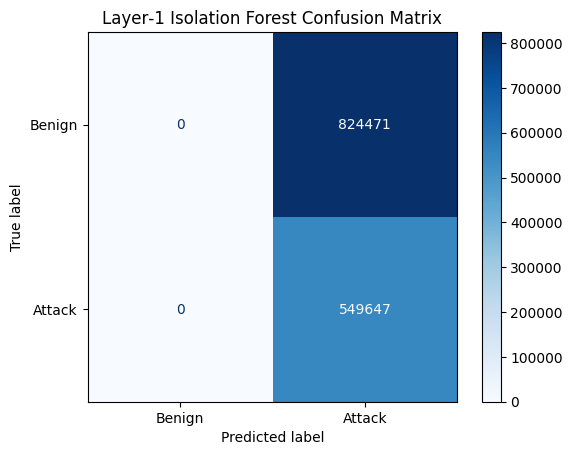

In [18]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Benign","Attack"]
).plot(cmap="Blues")
plt.title("Layer‑1 Isolation Forest Confusion Matrix")
plt.show()

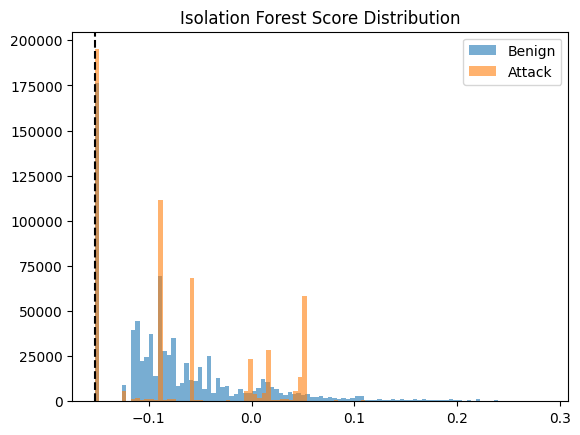

In [19]:
plt.hist(test_scores[y_test==0], bins=100, alpha=0.6, label="Benign")
plt.hist(test_scores[y_test==1], bins=100, alpha=0.6, label="Attack")
plt.axvline(best_thr, color="black", linestyle="--")
plt.legend()
plt.title("Isolation Forest Score Distribution")
plt.show()

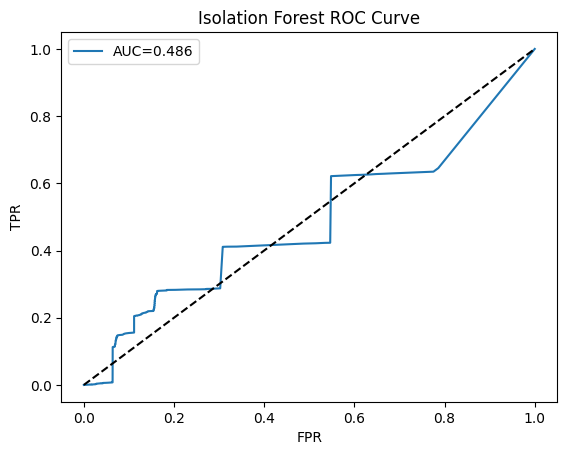

In [20]:
fpr, tpr, _ = roc_curve(y_test, test_scores)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Isolation Forest ROC Curve")
plt.legend()
plt.show()

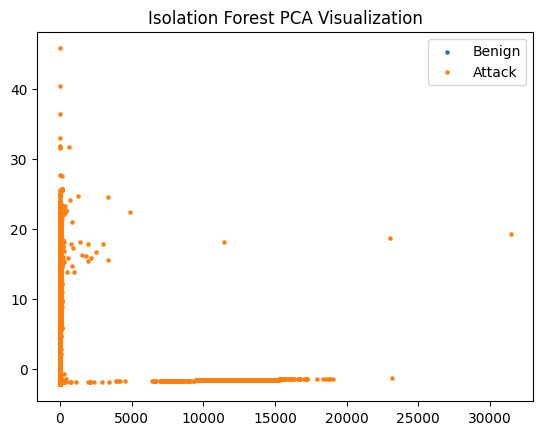

In [21]:
pca = PCA(n_components=2)
X2d = pca.fit_transform(X_test_s)

plt.scatter(X2d[y_pred==0,0], X2d[y_pred==0,1], s=5, label="Benign")
plt.scatter(X2d[y_pred==1,0], X2d[y_pred==1,1], s=5, label="Attack")
plt.legend()
plt.title("Isolation Forest PCA Visualization")
plt.show()

In [22]:
config = {
    "model": "Isolation Forest",
    "n_estimators": IF_N_ESTIMATORS,
    "max_samples": IF_MAX_SAMPLES,
    "threshold": float(best_thr),
    "features": APPLICATION_FEATURES
}

with open(f"{MODELS_DIR}/layer1_iforest_config.json","w") as f:
    json.dump(config, f, indent=2)

print("Model & config saved.")

Model & config saved.
